In [319]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display




In [320]:

def cox_de_boor(x, knots, degree, i):
	"""
	Compute the value of the i-th B-spline basis function of given degree at x using the Cox-de Boor recursion formula.
	
	Parameters:
	x (torch.Tensor): The input value(s) where the B-spline is evaluated.
	knots (torch.Tensor): The knot sequence.
	degree (int): The degree of the B-spline.
	i (int): The index of the basis function.
	
	Returns:
	torch.Tensor: The value of the basis function at x.
	"""

	if degree == 0:
		return ((knots[i] <= x) & (x < knots[i + 1]) ).float()
	
	denom1 = knots[i + degree] - knots[i]
	denom2 = knots[i + degree + 1] - knots[i + 1]
	
	term1 = 0 if denom1 == 0 else ((x - knots[i]) / denom1) * cox_de_boor(x, knots, degree - 1, i)
	term2 = 0 if denom2 == 0 else ((knots[i + degree + 1] - x) / denom2) * cox_de_boor(x, knots, degree - 1, i + 1)
	
	return term1 + term2


def wrapped_cox_de_boor(x,knots, degree, i):
	return torch.maximum( torch.maximum(cox_de_boor(x,knots, degree, i), cox_de_boor(x+(2*torch.pi),knots, degree, i)), cox_de_boor(x-(2*torch.pi),knots, degree, i))



class MLP(nn.Module):
	def __init__(self, layer_sizes):
		super(MLP, self).__init__()
		layers = []
		for i in range(len(layer_sizes) - 1):
			layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
			if i < len(layer_sizes) - 2:  # No activation on last layer
				layers.append(nn.Tanh())
		self.network = nn.Sequential(*layers)
	
	def forward(self, x):
		return self.network(x)

class BlendedMLP(nn.Module):
    def __init__(self, n, layer_sizes, degree, knots):
        super(BlendedMLP, self).__init__()
        self.mlps = nn.ModuleList([MLP(layer_sizes) for _ in range(n)])
        self.n = n
        self.degree = degree
        self.knots = knots
        self.wrapped_knots = torch.cat([self.knots, self.knots[1:] + 2 * torch.pi])
        print(self.wrapped_knots)

        self.fake_mlps = [lambda x: (torch.rand(1) + torch.sin(5*x)+2)*torch.stack([torch.cos(x), torch.sin(x)]).squeeze().transpose(0,1) for _ in range(n)]

        x = torch.arange(self.knots[0], self.knots[-1], 0.001)

        for i in range(n):
            plt.plot(x, wrapped_cox_de_boor(x, self.wrapped_knots[i : i + self.degree + 2], self.degree, 0))
        
        y = torch.tensor([0] * len(knots))
        plt.scatter(knots, y)
        plt.show()

    def component(self, x, i):
        return self.mlps[i](torch.stack([torch.sin(x), torch.cos(x)]).squeeze().transpose(0,1)) * wrapped_cox_de_boor(x - self.wrapped_knots[i], self.wrapped_knots[i:i+self.degree+2] - self.wrapped_knots[i], self.degree, 0)
        
    def forward(self, x):
        return sum(
            (self.mlps[i](torch.stack([torch.sin(x), torch.cos(x)]).squeeze().transpose(0,1)) * wrapped_cox_de_boor(x - self.wrapped_knots[i], self.wrapped_knots[i : i + self.degree + 2] - self.wrapped_knots[i], self.degree, 0))
            for i in range(self.n)
        )
    

tensor([ 0.0000,  0.6283,  1.2566,  1.8850,  2.5133,  3.1416,  3.7699,  4.3982,
         5.0265,  5.6549,  6.9115,  7.5398,  8.1681,  8.7965,  9.4248, 10.0531,
        10.6814, 11.3097, 11.9381])


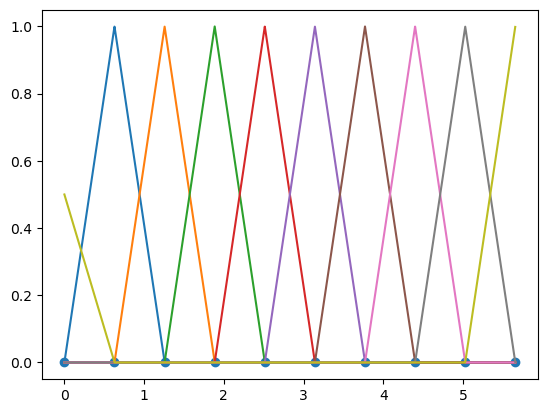

In [321]:
	   
# Example usage

layer_sizes = [2, 16, 16, 2]  # Example structure: 1 input, two hidden layers (16 neurons), 1 output
degree=1
#knots = torch.tensor([0,0.5,1.0, 1.7,3.0, 4.2, 5.0, 5.8])
knots = 2*torch.pi * torch.arange(0,1.0,0.1)
n = len(knots)-1  # Number of MLPs


blended_mlp = BlendedMLP(n, layer_sizes, degree, knots = knots)

#f = lambda theta: torch.stack([torch.cos(theta), torch.sin(theta)]).squeeze().transpose(0,1)
f = lambda theta: torch.stack([torch.cos(theta), torch.sin(theta)]).squeeze().transpose(0,1) * (1+ 0.1*torch.sin(10*theta))

# Training all models jointly
optimizer = optim.Adam(blended_mlp.parameters(), lr=0.1)
criterion = nn.MSELoss()

# Dummy training data
theta_train = 2 * torch.pi * torch.rand(10000, 1)
target_train = f(theta_train)











In [322]:

def update_plot( **slider_values ):
    theta = 2 * torch.pi * torch.arange(0, 1.005, 0.005).unsqueeze(-1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Extract weights from slider values
    weights = [slider_values[f'weight_{i}'] for i in range(blended_mlp.n)]

    knot_components = []
    components = []
    for i in range(blended_mlp.n):
        component = weights[i] * blended_mlp.component(theta, i=i)
        axes[0].plot(component.detach()[:, 0], component.detach()[:, 1], linewidth=1, label=f"Comp. {i}", alpha=1.0)
        components.append(component)

        knot_components.append(weights[i] * blended_mlp.component(blended_mlp.knots.unsqueeze(-1), i=i))

    #blended_mlp.knots.squeeze()
    axes[0].legend()
    axes[0].set_xlim([-2, 2])
    axes[0].set_ylim([-2, 2])
    axes[0].set_title("Components")

    target = f(theta)
    output = sum(components)
    output_knots = sum(knot_components)

    axes[1].plot(target.detach()[:, 0], target.detach()[:, 1], color='red', linewidth=1)
    axes[1].plot(output.detach()[:, 0], output.detach()[:, 1], color='blue', linewidth=1)
    axes[1].scatter(output_knots.detach()[:,0], output_knots.detach()[:,1], color='blue', alpha=0.5, s=100.0)
    for i, (x, y) in enumerate(output_knots.detach()):
        axes[1].text(x, y, str(i), fontsize=12, ha='right', va='bottom', color='black')
    
    axes[1].set_title("Combined Shape")
    axes[1].axis("equal")
    axes[1].set_xlim([-2, 2])
    axes[1].set_ylim([-2, 2])

    plt.show()


def show():
    # Generate sliders for each weight
    weight_sliders = {
        f'weight_{i}': widgets.FloatSlider(min=0, max=1, step=0.1, value=1, description=f"W{i}") for i in range(blended_mlp.n)
    }
    
    # Create interactive widget with all sliders
    interactive_plot = widgets.interactive(update_plot, **weight_sliders)
    
    # Display sliders and plot
    display(interactive_plot)

In [323]:
show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…

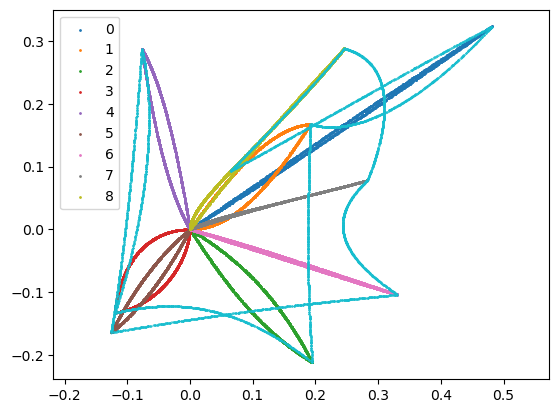

In [324]:
for i in range(n):
    component = blended_mlp.component(theta_test, i=i)
    plt.scatter(component.detach()[:,0], component.detach()[:,1], s=1.0, label=i, alpha=1.0)
plt.legend()

combined = blended_mlp(theta_train)
plt.scatter(combined.detach()[:,0], combined.detach()[:,1], s=0.1)
plt.axis('equal')
plt.show()


In [325]:

# Training loop
for epoch in range(1000):
	optimizer.zero_grad()
	output_train = blended_mlp(theta_train)
	loss = criterion(output_train, target_train)
	loss.backward()
	optimizer.step()
	
	if epoch % 10 == 0:
		print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
		#print(output_train.shape)




#Interpret
#blended_mlp.view_patches()

Epoch 0, Loss: 0.4530
Epoch 10, Loss: 0.0344
Epoch 20, Loss: 0.0156
Epoch 30, Loss: 0.0068
Epoch 40, Loss: 0.0039
Epoch 50, Loss: 0.0026
Epoch 60, Loss: 0.0022
Epoch 70, Loss: 0.0019
Epoch 80, Loss: 0.0017
Epoch 90, Loss: 0.0016
Epoch 100, Loss: 0.0015
Epoch 110, Loss: 0.0013
Epoch 120, Loss: 0.0010
Epoch 130, Loss: 0.0010
Epoch 140, Loss: 0.0009
Epoch 150, Loss: 0.0006
Epoch 160, Loss: 0.0013
Epoch 170, Loss: 0.0005
Epoch 180, Loss: 0.0003
Epoch 190, Loss: 0.0002
Epoch 200, Loss: 0.0002
Epoch 210, Loss: 0.0001
Epoch 220, Loss: 0.0002
Epoch 230, Loss: 0.0003
Epoch 240, Loss: 0.0001
Epoch 250, Loss: 0.0001
Epoch 260, Loss: 0.0001
Epoch 270, Loss: 0.0001
Epoch 280, Loss: 0.0001
Epoch 290, Loss: 0.0004
Epoch 300, Loss: 0.0001
Epoch 310, Loss: 0.0001
Epoch 320, Loss: 0.0000
Epoch 330, Loss: 0.0000
Epoch 340, Loss: 0.0000
Epoch 350, Loss: 0.0000
Epoch 360, Loss: 0.0009
Epoch 370, Loss: 0.0005
Epoch 380, Loss: 0.0001
Epoch 390, Loss: 0.0002
Epoch 400, Loss: 0.0003
Epoch 410, Loss: 0.0001
Epo

In [326]:
show()

interactive(children=(FloatSlider(value=1.0, description='W0', max=1.0), FloatSlider(value=1.0, description='W…